# 10 - Engagement Intelligence

Day 3, step 10. No ML here, and none is needed - these are aggregations. The build
notes are right that a model adds nothing until there is a target worth predicting.

> **Numbering note.** The build notes label this `09_engagement_intelligence`, which
> collides with step 9 (model versioning). Renumbered to 10 so the notebook order
> matches the checklist order.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.services import engagement_service as engagement
from app.utils.config import PROCESSED_FILES

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = engagement.load_engagement()
print(df.shape)
df.head()

(1470, 12)


,EmployeeID,Department,JobRole,ReviewPeriod,EngagementScore,JobSatisfactionScore,JobInvolvementScore,EnvironmentSatisfactionScore,WorkLifeBalanceScore,RelationshipSatisfactionScore,PerformanceRating,TrainingTimesLastYear
0,1,Sales,Sales Executive,2026-H1,53.3,100.0,66.7,33.3,0.0,0.0,3,0
1,2,Research & Development,Research Scientist,2026-H1,51.7,33.3,33.3,66.7,66.7,100.0,4,3
2,4,Research & Development,Laboratory Technician,2026-H1,61.7,66.7,33.3,100.0,66.7,33.3,3,3
3,5,Research & Development,Research Scientist,2026-H1,73.4,66.7,66.7,100.0,66.7,66.7,3,3
4,7,Research & Development,Laboratory Technician,2026-H1,46.7,33.3,66.7,0.0,66.7,100.0,3,3


## Headline figures

In [2]:
summary = engagement.summary(df)
pd.Series(summary).to_frame("value")

,value
employees,1470.0
average_engagement,57.7
median_engagement,58.3
std_engagement,15.2
lowest,8.3
highest,100.0
pct_low_engagement,11.6
pct_high_engagement,24.6


## Distribution

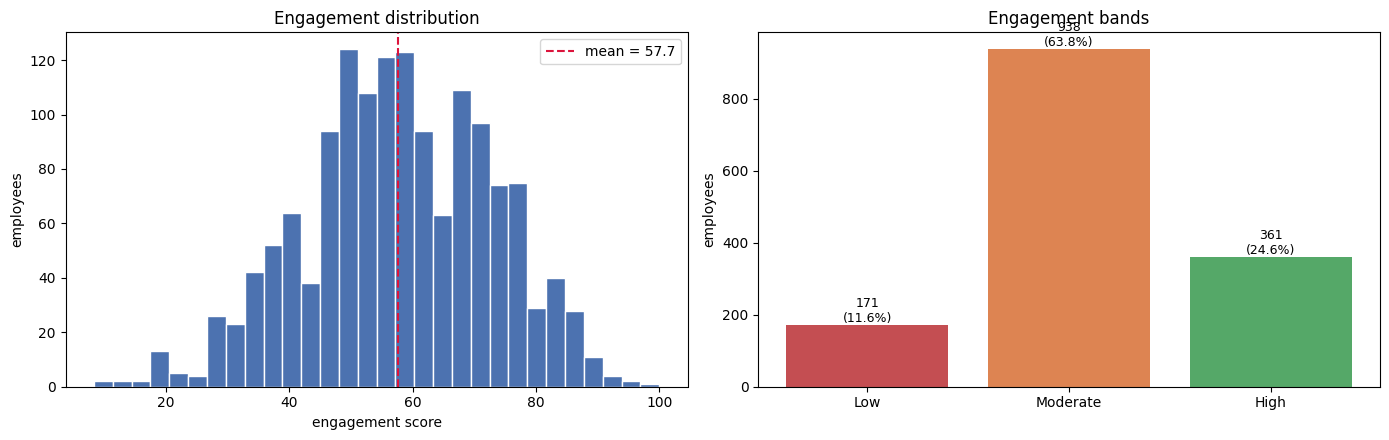

,band,employees,percent
0,Low,171,11.6
1,Moderate,938,63.8
2,High,361,24.6


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.hist(df["EngagementScore"], bins=30, color="#4C72B0", edgecolor="white")
ax1.axvline(summary["average_engagement"], color="crimson", linestyle="--",
            label=f"mean = {summary['average_engagement']}")
ax1.set(xlabel="engagement score", ylabel="employees", title="Engagement distribution")
ax1.legend()

bands = engagement.band_distribution(df)
ax2.bar(bands["band"], bands["employees"], color=["#C44E52", "#DD8452", "#55A868"])
for i, (n, pct) in enumerate(zip(bands["employees"], bands["percent"])):
    ax2.text(i, n + 8, f"{n}\n({pct}%)", ha="center", fontsize=9)
ax2.set(ylabel="employees", title="Engagement bands")
plt.tight_layout()
plt.show()

bands

The distribution is lumpy rather than smooth. That is a direct consequence of the
source data: engagement is built from five 1-4 Likert items, so only a finite set of
weighted combinations can occur. It is a property of the instrument, not a data
error - and a reason to treat small differences between employees as noise.

## By department

The build notes' one-liner, with the surrounding context that makes it actionable:

```python
performance_df.groupby('Department')['EngagementScore'].mean().sort_values()
```

In [4]:
by_department = engagement.by_department(df)
by_department

,Department,headcount,avg_engagement,median_engagement,avg_performance,pct_low
0,Sales,446,57.63,56.7,3.14,12.78
1,Human Resources,63,57.71,58.3,3.14,11.11
2,Research & Development,961,57.74,58.3,3.16,11.13


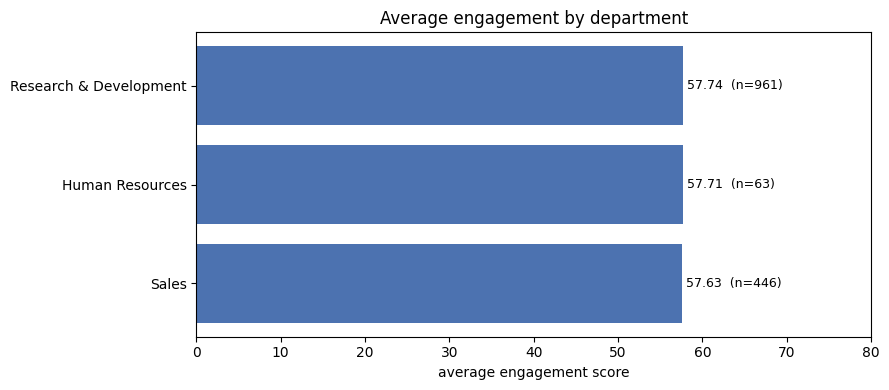

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(by_department["Department"], by_department["avg_engagement"], color="#4C72B0")
for i, (v, n) in enumerate(zip(by_department["avg_engagement"], by_department["headcount"])):
    ax.text(v + 0.4, i, f"{v}  (n={n})", va="center", fontsize=9)
ax.set(xlabel="average engagement score", title="Average engagement by department")
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

The spread between departments is a couple of points on a 100-point scale - small
enough that, with these headcounts, it would be a mistake to act on the ranking
alone. The variation *within* each department is far larger than the variation
between them, which is why the individual-level list below is the more useful output.

## By role

In [6]:
engagement.by_role(df)

,JobRole,headcount,avg_engagement
0,Human Resources,52,56.64
1,Laboratory Technician,259,56.71
2,Research Director,80,56.74
3,Sales Representative,83,57.48
4,Sales Executive,326,57.68
5,Manufacturing Director,145,58.21
6,Healthcare Representative,131,58.28
7,Research Scientist,292,58.31
8,Manager,102,58.54


## The employees HR should actually look at

In [7]:
lowest = engagement.lowest_engaged(15, df)
lowest

,EmployeeID,Department,JobRole,EngagementScore,JobSatisfactionScore,WorkLifeBalanceScore,PerformanceRating,EngagementBand
0,1210,Research & Development,Research Scientist,8.3,0.0,0.0,3,Low
1,1033,Research & Development,Healthcare Representative,10.0,33.3,0.0,3,Low
2,1019,Research & Development,Laboratory Technician,11.7,0.0,33.3,3,Low
3,1961,Sales,Sales Representative,13.3,0.0,33.3,3,Low
4,1522,Research & Development,Research Scientist,15.0,0.0,0.0,3,Low
5,1622,Research & Development,Manufacturing Director,15.0,0.0,33.3,4,Low
6,1083,Research & Development,Laboratory Technician,18.3,0.0,66.7,3,Low
7,1136,Research & Development,Research Scientist,18.3,33.3,0.0,3,Low
8,1420,Research & Development,Laboratory Technician,18.3,0.0,66.7,4,Low
9,1439,Sales,Sales Representative,18.3,0.0,66.7,3,Low


## High performers who are disengaged

The most expensive group to lose: rated 4 on performance, engagement below 40. They
are productive now and demonstrably unhappy.

In [8]:
at_risk = engagement.high_performer_low_engagement(df)
print(f"{len(at_risk)} high performers with engagement below 40")
at_risk.head(15)

27 high performers with engagement below 40


,EmployeeID,Department,JobRole,EngagementScore,PerformanceRating
0,1622,Research & Development,Manufacturing Director,15.0,4
1,1420,Research & Development,Laboratory Technician,18.3,4
2,33,Research & Development,Research Scientist,20.0,4
3,145,Research & Development,Healthcare Representative,20.0,4
4,878,Human Resources,Human Resources,25.0,4
5,1458,Research & Development,Laboratory Technician,26.7,4
6,1758,Sales,Sales Executive,28.3,4
7,235,Sales,Sales Representative,28.3,4
8,1237,Research & Development,Manufacturing Director,30.0,4
9,1108,Research & Development,Research Scientist,31.6,4


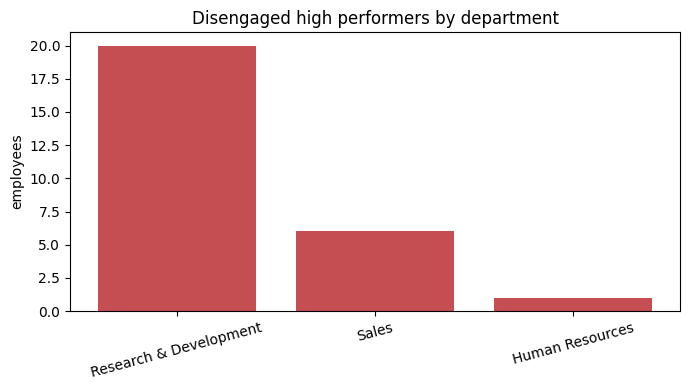

In [9]:
if len(at_risk):
    counts = at_risk["Department"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(counts.index, counts.values, color="#C44E52")
    ax.set(ylabel="employees", title="Disengaged high performers by department")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## Engagement and attrition - with a caveat that matters

The obvious next question is whether engagement predicts who leaves. It appears to,
and the appearance is partly manufactured.

In [10]:
employees = pd.read_csv(PROCESSED_FILES["attrition"])
merged = employees[["EmployeeID", "AttritionFlag"]].merge(
    df[["EmployeeID", "EngagementScore"]], on="EmployeeID")

by_outcome = merged.groupby("AttritionFlag")["EngagementScore"].agg(["mean", "median", "count"])
by_outcome.index = ["stayed", "left"]
print(by_outcome.round(2).to_string())
print(f"\npoint-biserial correlation with attrition: "
      f"{merged['EngagementScore'].corr(merged['AttritionFlag']):.4f}")

         mean  median  count
stayed  59.04    58.4   1233
left    50.73    51.7    237

point-biserial correlation with attrition: -0.2009


> **This is not independent evidence.** `EngagementScore` is a deterministic weighted
> combination of `JobSatisfaction`, `JobInvolvement`, `EnvironmentSatisfaction`,
> `WorkLifeBalance` and `RelationshipSatisfaction` - five columns the attrition model
> already uses as features. Leavers scoring lower on engagement is the same fact as
> leavers scoring lower on job satisfaction, restated.
>
> It is reported because the relationship is real and useful for framing a
> conversation, but it must not be presented as a second, corroborating signal, and
> engagement is never fed back into the model as a feature. See
> `scripts/build_derived_sources.py` and `docs/data_relationships.md`.

C:\Users\Devyansh Aggarwal\AppData\Local\Temp\ipykernel_26252\1169180818.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([merged.loc[merged.AttritionFlag == 0, "EngagementScore"],


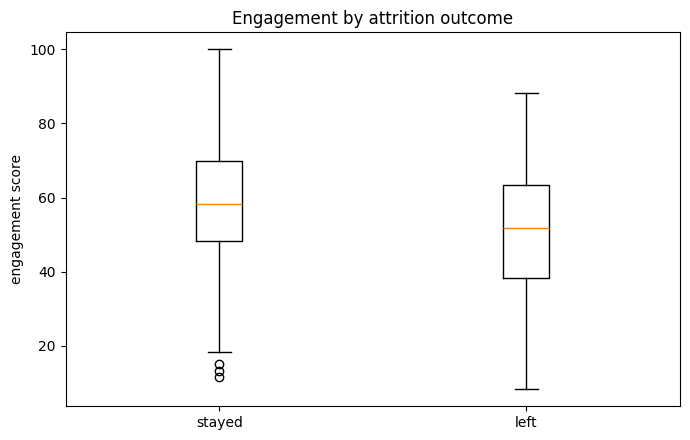

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([merged.loc[merged.AttritionFlag == 0, "EngagementScore"],
            merged.loc[merged.AttritionFlag == 1, "EngagementScore"]],
           labels=["stayed", "left"])
ax.set(ylabel="engagement score", title="Engagement by attrition outcome")
plt.tight_layout()
plt.show()

## What a model would add here

Nothing yet, and it is worth being specific about why. There is no engagement
*target* to predict - the score is an input, not an outcome. The options that would
make sense later:

* **Regression**, once engagement is measured over multiple periods, to predict next
  quarter's score from this quarter's conditions.
* **KMeans segmentation**, to find employee groups with distinct engagement profiles
  rather than assuming departments are the right grouping.

Both need data this snapshot does not contain. Building either now would be modelling
for its own sake.